# Data Management: Relational Database Design & SQL

This notebook demonstrates how to import the cleaned dataset (353,422 rows x 39 cols) produced by the data preparation pipeline into a relational database, covering the complete workflow from conceptual design to physical implementation.

**Learning Objectives:**
1. **Conceptual Design** — ER model (entities, relationships, cardinalities)
2. **Logical Design** — ER-to-Relational mapping algorithm (3-step)
3. **SQL DDL/DML** — CREATE TABLE, INSERT, UPDATE, DELETE, SELECT (9 query types)
4. **Performance & Scalability** — INDEX, EXPLAIN QUERY PLAN, RDBMS vs CSV reflection

**Database Persistence:** We use `sqlite3.connect('outputs/transfermarkt.db')` to create a persistent `.db` file, embodying the concept of persistent storage. Subsequent EDA/modeling notebooks can connect directly to this database for querying.

In [1]:
import sqlite3
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from matplotlib.patches import FancyBboxPatch, FancyArrowPatch
from matplotlib.patches import Ellipse
import time
import os

# Load cleaned dataset
df = pd.read_csv('outputs/cleaned/cleaned_player_dataset.csv', low_memory=False)
print(f'Dataset shape: {df.shape}')
print(f'Columns ({len(df.columns)}): {list(df.columns)}')

Dataset shape: (353422, 39)
Columns (39): ['player_id', 'season', 'goals', 'assists', 'own_goals', 'minutes_played', 'yellow_cards', 'penalty_goals', 'goals_conceded', 'clean_sheets', 'appearances', 'red_cards', 'primary_team_id', 'primary_team_name', 'num_teams', 'player_name', 'height', 'citizenship', 'is_eu', 'position', 'main_position', 'foot', 'market_value', 'market_value_start', 'injury_count', 'total_days_missed', 'total_games_missed', 'max_single_injury_days', 'intl_caps', 'intl_goals', 'competition_id', 'competition_name', 'club_division', 'num_transfers', 'total_transfer_fee', 'max_transfer_fee', 'had_loan', 'ds_b_league', 'age']


In [2]:
# Quick data exploration
print('=== Data Types ===')
print(df.dtypes)
print(f'\n=== Missing Values (top 10) ===')
missing = df.isnull().sum()
print(missing[missing > 0].sort_values(ascending=False).head(10))
print(f'\n=== First 3 Rows ===')
df.head(3)

=== Data Types ===
player_id                   int64
season                     object
goals                     float64
assists                     int64
own_goals                   int64
minutes_played            float64
yellow_cards                int64
penalty_goals               int64
goals_conceded              int64
clean_sheets                int64
appearances                 int64
red_cards                   int64
primary_team_id             int64
primary_team_name          object
num_teams                   int64
player_name                object
height                    float64
citizenship                object
is_eu                        bool
position                   object
main_position              object
foot                       object
market_value              float64
market_value_start        float64
injury_count              float64
total_days_missed         float64
total_games_missed        float64
max_single_injury_days    float64
intl_caps                 flo

,player_id,season,goals,assists,own_goals,minutes_played,yellow_cards,penalty_goals,goals_conceded,clean_sheets,...,intl_goals,competition_id,competition_name,club_division,num_transfers,total_transfer_fee,max_transfer_fee,had_loan,ds_b_league,age
0,1,04/05,3.0,1,0,5500.0,0,0,0,0,...,11.0,RLB3,Regionalliga Bayern,Regionalliga Bayern,1.0,0.0,0.0,False,NaN,24.312115
1,1,06/07,0.0,0,0,0.0,0,0,0,0,...,11.0,OLRP,Oberliga Rheinland-Pfalz/Saar,Oberliga Rheinland-Pfalz/Saar,1.0,0.0,0.0,False,NaN,26.310746
2,4,04/05,0.0,0,0,0.0,0,0,0,0,...,33.0,GB2,Championship,Championship,3.0,0.0,0.0,False,NaN,36.854209


## Section 1: Conceptual Design — ER Model

Based on the 39 columns in the cleaned dataset, we identify **7 entities**, following the three ER modeling principles (slides W7):
- **Application need**: Each entity corresponds to an independent business concept
- **Avoid redundancy**: Splitting entities eliminates redundant storage
- **Keep it simple**: No over-decomposition (e.g., Team has only a name attribute and is not modeled as a separate entity)

### 7 Entities

| Entity | PK | Attributes |
|--------|-----|------------|
| **Player** | player_id | player_name, height, citizenship, is_eu, position, main_position, foot |
| **Season_Performance** | (player_id, season) | goals, assists, own_goals, minutes_played, yellow_cards, red_cards, clean_sheets, goals_conceded, appearances, penalty_goals, num_teams, primary_team_id, primary_team_name, competition_id, age |
| **Market_Valuation** | (player_id, season) | market_value, market_value_start |
| **Injury_Record** | (player_id, season) | injury_count, total_days_missed, total_games_missed, max_single_injury_days |
| **International_Career** | player_id | intl_caps, intl_goals |
| **Transfer_Record** | (player_id, season) | num_transfers, total_transfer_fee, max_transfer_fee, had_loan |
| **League** | competition_id | competition_name, club_division |

### Relationships & Cardinalities
- Player --1:N-- Season_Performance
- Player --1:N-- Market_Valuation
- Player --1:N-- Injury_Record
- Player --1:1-- International_Career
- Player --1:N-- Transfer_Record
- League --1:N-- Season_Performance (via competition_id)

### Exclusion Note
- **ds_b_league**: 91.9% missing values; only used for backfilling league information in the pipeline — not modeled as an entity attribute

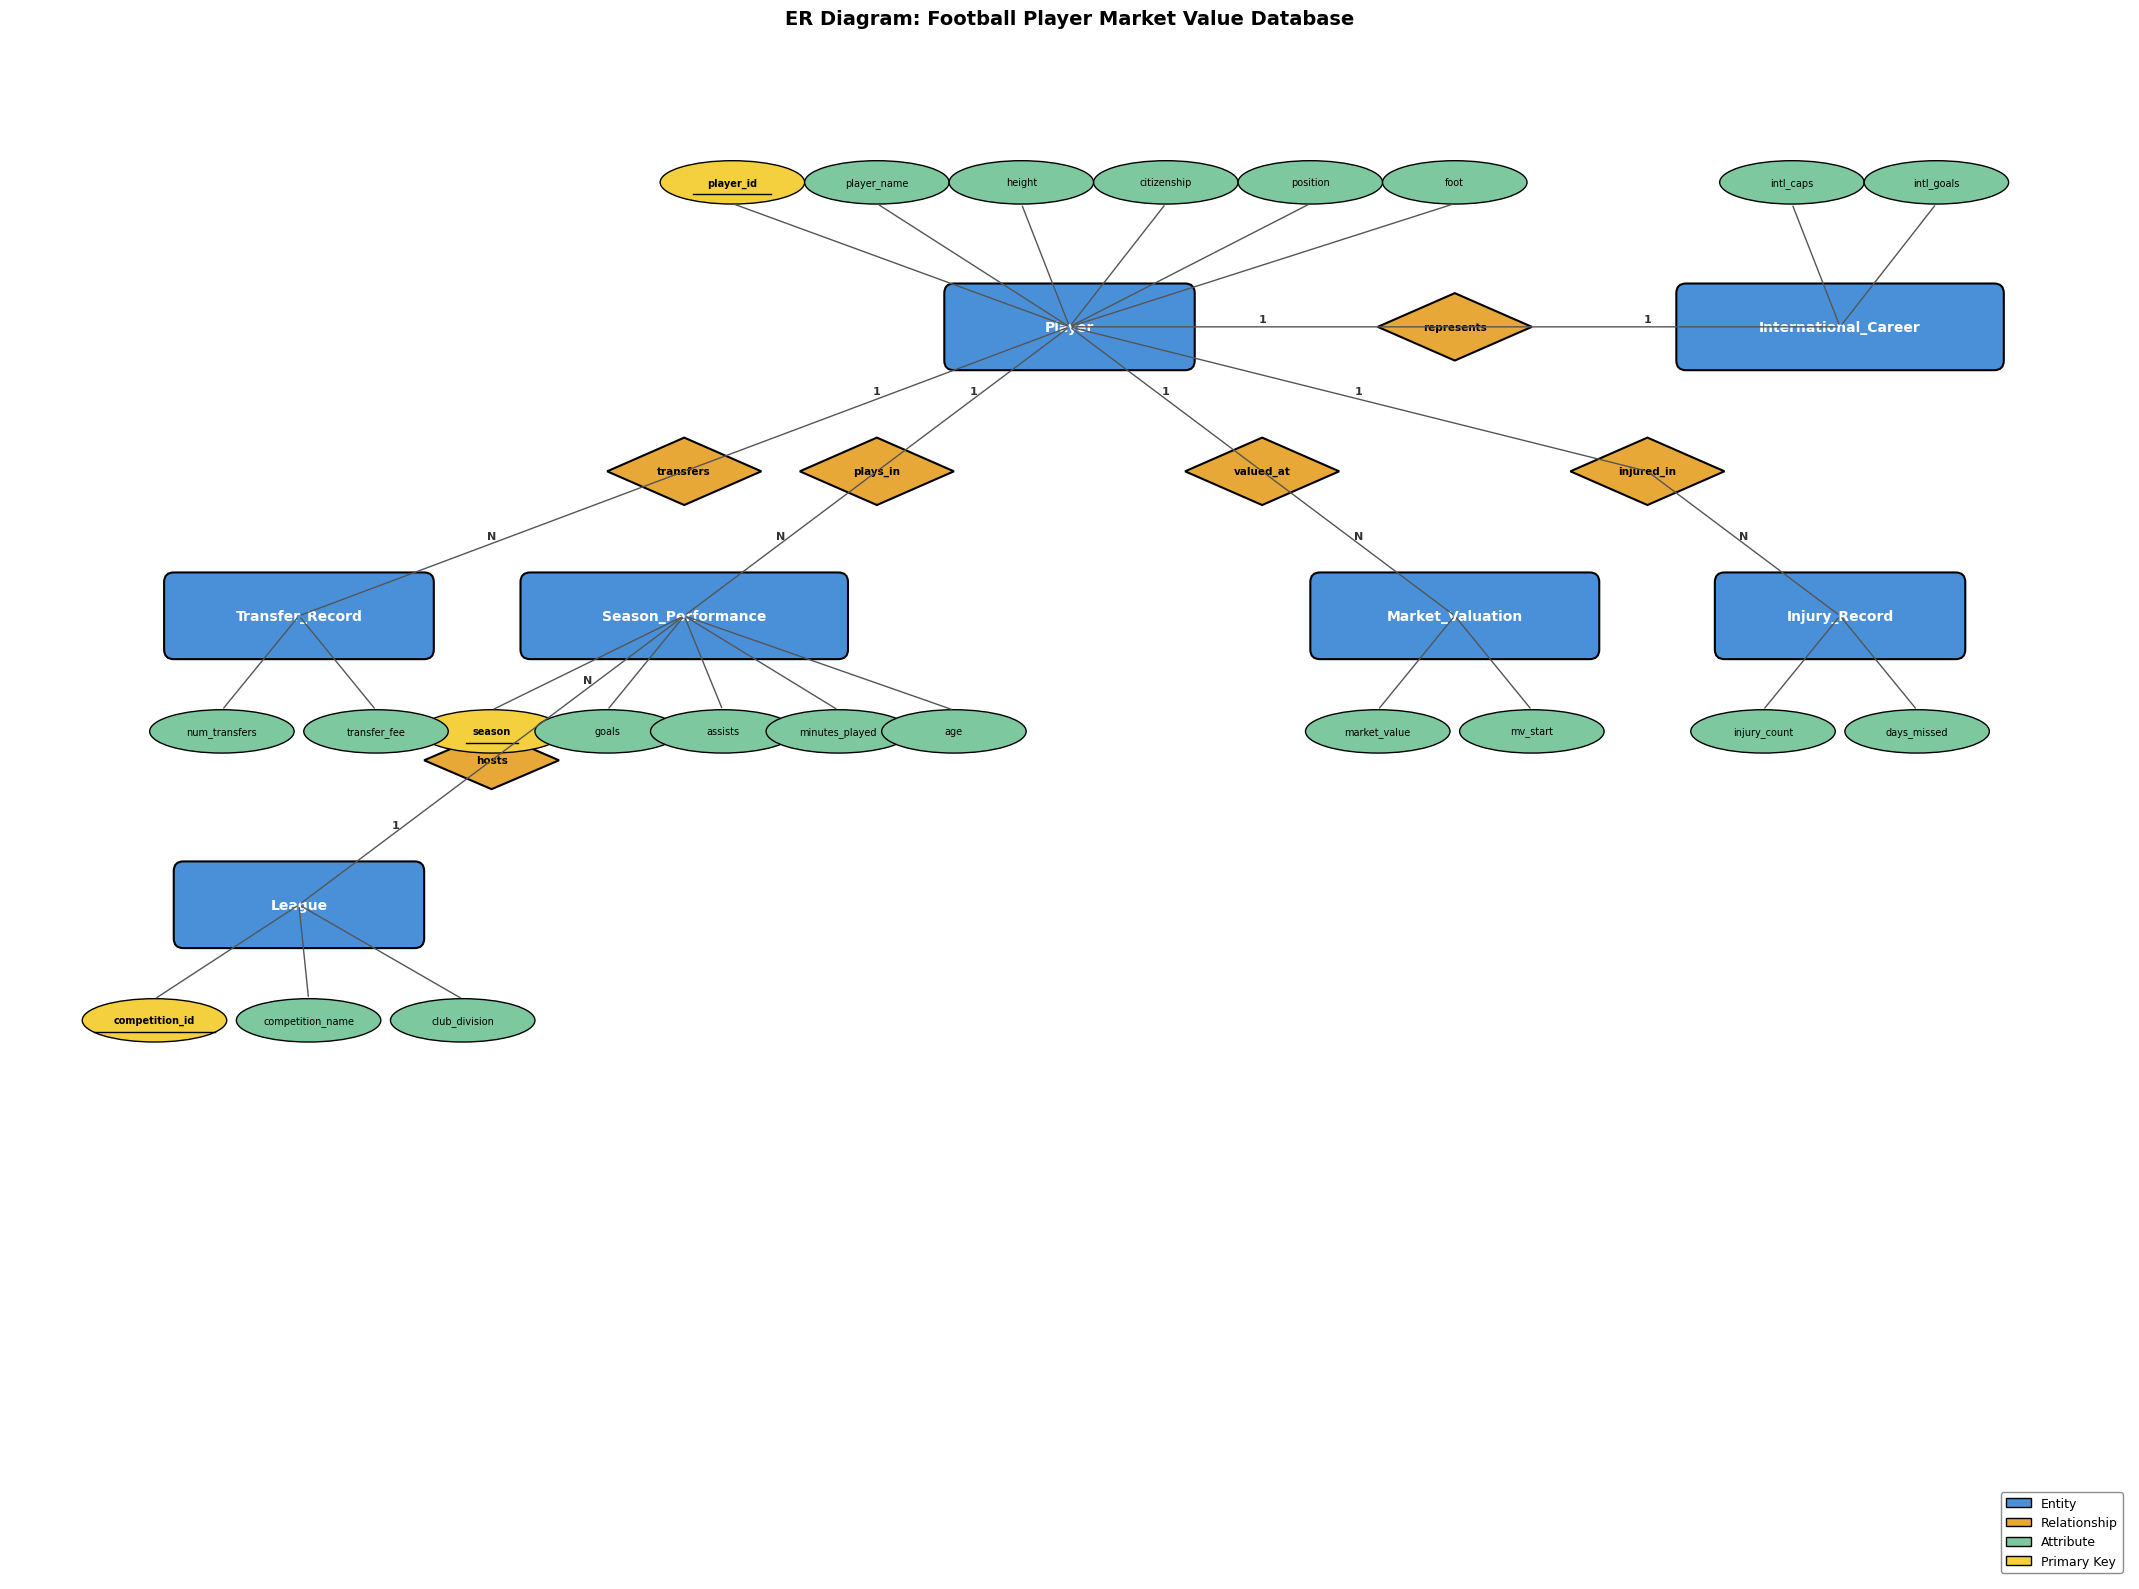

In [3]:
# ER Diagram using classic notation
fig, ax = plt.subplots(1, 1, figsize=(22, 16))
ax.set_xlim(0, 22)
ax.set_ylim(0, 16)
ax.set_aspect('equal')
ax.axis('off')
fig.patch.set_facecolor('white')

# Colors
ENTITY_COLOR = '#4A90D9'
REL_COLOR = '#E8A838'
ATTR_COLOR = '#7EC8A0'
PK_COLOR = '#F4D03F'

def draw_entity(ax, x, y, name, w=2.4, h=0.7):
    box = FancyBboxPatch((x - w/2, y - h/2), w, h,
                         boxstyle='round,pad=0.1', facecolor=ENTITY_COLOR,
                         edgecolor='black', linewidth=1.5)
    ax.add_patch(box)
    ax.text(x, y, name, ha='center', va='center', fontsize=10,
            fontweight='bold', color='white')
    return (x, y)

def draw_relationship(ax, x, y, name, w=1.6, h=0.7):
    diamond = plt.Polygon([(x, y+h/2), (x+w/2, y), (x, y-h/2), (x-w/2, y)],
                          facecolor=REL_COLOR, edgecolor='black', linewidth=1.5)
    ax.add_patch(diamond)
    ax.text(x, y, name, ha='center', va='center', fontsize=7.5, fontweight='bold')
    return (x, y)

def draw_attribute(ax, x, y, name, is_pk=False):
    color = PK_COLOR if is_pk else ATTR_COLOR
    ellipse = Ellipse((x, y), 1.5, 0.45, facecolor=color,
                      edgecolor='black', linewidth=1)
    ax.add_patch(ellipse)
    txt = ax.text(x, y, name, ha='center', va='center', fontsize=7)
    if is_pk:
        txt.set_fontweight('bold')
        ax.plot([x - len(name)*0.045, x + len(name)*0.045], [y - 0.12, y - 0.12],
                color='black', linewidth=1)
    return (x, y)

def connect(ax, p1, p2, label='', offset=(0, 0.08)):
    ax.annotate('', xy=p2, xytext=p1,
                arrowprops=dict(arrowstyle='-', color='#555', linewidth=1))
    if label:
        mx, my = (p1[0]+p2[0])/2 + offset[0], (p1[1]+p2[1])/2 + offset[1]
        ax.text(mx, my, label, ha='center', va='center', fontsize=8,
                color='#333', fontweight='bold')

# === Draw Entities ===
e_player = draw_entity(ax, 11, 13, 'Player')
e_league = draw_entity(ax, 3, 7, 'League')
e_season = draw_entity(ax, 7, 10, 'Season_Performance', w=3.2)
e_market = draw_entity(ax, 15, 10, 'Market_Valuation', w=2.8)
e_injury = draw_entity(ax, 19, 10, 'Injury_Record', w=2.4)
e_intl = draw_entity(ax, 19, 13, 'International_Career', w=3.2)
e_transfer = draw_entity(ax, 3, 10, 'Transfer_Record', w=2.6)

# === Draw Relationships ===
r1 = draw_relationship(ax, 9, 11.5, 'plays_in')
r2 = draw_relationship(ax, 13, 11.5, 'valued_at')
r3 = draw_relationship(ax, 17, 11.5, 'injured_in')
r4 = draw_relationship(ax, 15, 13, 'represents')
r5 = draw_relationship(ax, 7, 11.5, 'transfers')
r6 = draw_relationship(ax, 5, 8.5, 'hosts', w=1.4, h=0.6)

# === Connect Entities to Relationships ===
connect(ax, e_player, r1, '1')
connect(ax, r1, e_season, 'N')
connect(ax, e_player, r2, '1')
connect(ax, r2, e_market, 'N')
connect(ax, e_player, r3, '1')
connect(ax, r3, e_injury, 'N')
connect(ax, e_player, r4, '1')
connect(ax, r4, e_intl, '1')
connect(ax, e_player, r5, '1')
connect(ax, r5, e_transfer, 'N')
connect(ax, e_league, r6, '1')
connect(ax, r6, e_season, 'N')

# === Draw Key Attributes (selected, to keep diagram readable) ===
# Player attributes
attrs_player = [('player_id', True), ('player_name', False), ('height', False),
                ('citizenship', False), ('position', False), ('foot', False)]
for i, (name, is_pk) in enumerate(attrs_player):
    x = 7.5 + i * 1.5
    draw_attribute(ax, x, 14.5, name, is_pk)
    connect(ax, (x, 14.5 - 0.22), e_player)

# League attributes
attrs_league = [('competition_id', True), ('competition_name', False), ('club_division', False)]
for i, (name, is_pk) in enumerate(attrs_league):
    x = 1.5 + i * 1.6
    draw_attribute(ax, x, 5.8, name, is_pk)
    connect(ax, (x, 5.8 + 0.22), e_league)

# Season_Performance key attributes
attrs_sp = [('season', True), ('goals', False), ('assists', False),
            ('minutes_played', False), ('age', False)]
for i, (name, is_pk) in enumerate(attrs_sp):
    x = 5 + i * 1.2
    draw_attribute(ax, x, 8.8, name, is_pk)
    connect(ax, (x, 8.8 + 0.22), e_season)

# Market_Valuation attributes
attrs_mv = [('market_value', False), ('mv_start', False)]
for i, (name, is_pk) in enumerate(attrs_mv):
    x = 14.2 + i * 1.6
    draw_attribute(ax, x, 8.8, name, is_pk)
    connect(ax, (x, 8.8 + 0.22), e_market)

# Injury_Record attributes
attrs_ir = [('injury_count', False), ('days_missed', False)]
for i, (name, is_pk) in enumerate(attrs_ir):
    x = 18.2 + i * 1.6
    draw_attribute(ax, x, 8.8, name, is_pk)
    connect(ax, (x, 8.8 + 0.22), e_injury)

# International_Career attributes
attrs_ic = [('intl_caps', False), ('intl_goals', False)]
for i, (name, is_pk) in enumerate(attrs_ic):
    x = 18.5 + i * 1.5
    draw_attribute(ax, x, 14.5, name, is_pk)
    connect(ax, (x, 14.5 - 0.22), e_intl)

# Transfer_Record attributes
attrs_tr = [('num_transfers', False), ('transfer_fee', False)]
for i, (name, is_pk) in enumerate(attrs_tr):
    x = 2.2 + i * 1.6
    draw_attribute(ax, x, 8.8, name, is_pk)
    connect(ax, (x, 8.8 + 0.22), e_transfer)

# Legend
legend_items = [
    FancyBboxPatch((0, 0), 1, 0.3, boxstyle='round,pad=0.05', facecolor=ENTITY_COLOR, edgecolor='black'),
    FancyBboxPatch((0, 0), 1, 0.3, boxstyle='round,pad=0.05', facecolor=REL_COLOR, edgecolor='black'),
    Ellipse((0.5, 0.15), 1, 0.3, facecolor=ATTR_COLOR, edgecolor='black'),
    Ellipse((0.5, 0.15), 1, 0.3, facecolor=PK_COLOR, edgecolor='black'),
]
legend_labels = ['Entity', 'Relationship', 'Attribute', 'Primary Key']
ax.legend(legend_items, legend_labels, loc='lower right', fontsize=9,
          framealpha=0.9, edgecolor='gray')

ax.set_title('ER Diagram: Football Player Market Value Database', fontsize=14, fontweight='bold', pad=10)
plt.tight_layout()
plt.show()

### Design Decisions

1. **International_Career as a separate entity**: Although it has a 1:1 relationship with Player, intl_caps/intl_goals have many NULLs (non-international players). Storing them separately avoids sparsifying the Player table.

2. **No separate Team table**: `primary_team_id` + `primary_team_name` remain in Season_Performance. Reason: the slides explicitly state "An entity type is justified if it represents more than just the name of an object, or it is the n-part of a 1:n relationship." In our data, Team has only a name attribute and is on the 1-part side — it does not meet the criteria for a standalone entity.

3. **age in Season_Performance**: Age is a per-season attribute. Placing it in the Player table would only capture a single point in time, while Season_Performance correctly tracks it per season.

4. **ds_b_league not modeled**: 91.9% missing; only used for backfilling league info in the pipeline — not suitable as an entity attribute.

## Section 2: Logical Design — ER to Relational Mapping

We apply the **3-step mapping algorithm** from W8 slides (Page 45):

### Step 1: Each entity type → relation with same attributes

```
Player(player_id, player_name, height, citizenship, is_eu, position, main_position, foot)
Season_Performance(player_id, season, goals, assists, own_goals, minutes_played, ...)
Market_Valuation(player_id, season, market_value, market_value_start)
Injury_Record(player_id, season, injury_count, total_days_missed, ...)
International_Career(player_id, intl_caps, intl_goals)
Transfer_Record(player_id, season, num_transfers, total_transfer_fee, ...)
League(competition_id, competition_name, club_division)
```

### Step 2: Each relationship type → relation with FK attributes

```
plays_in(player_id, season)          → merged into Season_Performance
valued_at(player_id, season)         → merged into Market_Valuation
injured_in(player_id, season)        → merged into Injury_Record
represents(player_id)                → merged into International_Career
transfers(player_id, season)         → merged into Transfer_Record
hosts(competition_id, player_id, season) → merged into Season_Performance
```

### Step 3: Refine — merge 1:N relationships into N-side table

All relationship relations are merged into the N-side tables (standard practice for 1:N), eliminating the need for standalone relationship tables.

- `player_id` appears as an FK in all child tables
- `competition_id` appears as an FK in Season_Performance
- NOT NULL constraints for mandatory fields
- CHECK constraints for domain validation

### Final Relational Schema

Underlined attributes denote Primary Keys:

```
Player(__player_id__, player_name, height, citizenship, is_eu, position, main_position, foot)

League(__competition_id__, competition_name, club_division)

Season_Performance(__player_id__ [FK→Player], __season__, goals, assists, own_goals,
    minutes_played, yellow_cards, red_cards, clean_sheets, goals_conceded, appearances,
    penalty_goals, num_teams, primary_team_id, primary_team_name,
    competition_id [FK→League], age)

Market_Valuation(__player_id__ [FK→Player], __season__, market_value, market_value_start)

Injury_Record(__player_id__ [FK→Player], __season__, injury_count, total_days_missed,
    total_games_missed, max_single_injury_days)

International_Career(__player_id__ [FK→Player], intl_caps, intl_goals)

Transfer_Record(__player_id__ [FK→Player], __season__, num_transfers, total_transfer_fee,
    max_transfer_fee, had_loan)
```

Merge rationale: All 1:N relationships are merged into the N-side table; the 1:1 International_Career remains separate (to reduce NULLs in Player). This yields the most concise structure with no redundant relationship tables.

## Section 3: SQL DDL — Database Creation

### 3.1 CREATE TABLE

We use SQLite as our RDBMS to create a persistent database file. DDL (Data Definition Language) defines the database structure:
- `CREATE TABLE` defines table schemas
- `PRIMARY KEY`, `FOREIGN KEY` define integrity constraints
- `NOT NULL`, `CHECK` define domain constraints
- `PRAGMA foreign_keys = ON` enables SQLite's foreign key constraint enforcement

In [4]:
# Remove existing db file if present (fresh start)
db_path = 'outputs/transfermarkt.db'
if os.path.exists(db_path):
    os.remove(db_path)

conn = sqlite3.connect(db_path)
cur = conn.cursor()

# Enable foreign key constraints
cur.execute('PRAGMA foreign_keys = ON')
print(f'Database created at: {db_path}')
print(f'Foreign keys enabled: {cur.execute("PRAGMA foreign_keys").fetchone()[0]}')

Database created at: outputs/transfermarkt.db
Foreign keys enabled: 1


In [5]:
# Parent tables: Player, League (must be created first — referenced by FKs)

cur.execute('''
CREATE TABLE Player (
    player_id     INTEGER PRIMARY KEY,
    player_name   TEXT,
    height        REAL,
    citizenship   TEXT,
    is_eu         INTEGER CHECK (is_eu IN (0, 1) OR is_eu IS NULL),
    position      TEXT,
    main_position TEXT,
    foot          TEXT CHECK (foot IN ('right', 'left', 'both') OR foot IS NULL)
)
''')

cur.execute('''
CREATE TABLE League (
    competition_id   TEXT PRIMARY KEY,
    competition_name TEXT NOT NULL,
    club_division    TEXT
)
''')

conn.commit()
print('Created: Player, League')

Created: Player, League


In [6]:
# Child tables: reference Player and/or League via foreign keys

cur.execute('''
CREATE TABLE Season_Performance (
    player_id         INTEGER NOT NULL,
    season            TEXT NOT NULL,
    goals             REAL,
    assists           INTEGER,
    own_goals         INTEGER,
    minutes_played    REAL,
    yellow_cards      INTEGER,
    red_cards         INTEGER,
    clean_sheets      INTEGER,
    goals_conceded    INTEGER,
    appearances       INTEGER,
    penalty_goals     INTEGER,
    num_teams         INTEGER,
    primary_team_id   INTEGER,
    primary_team_name TEXT,
    competition_id    TEXT,
    age               REAL,
    PRIMARY KEY (player_id, season),
    FOREIGN KEY (player_id) REFERENCES Player(player_id),
    FOREIGN KEY (competition_id) REFERENCES League(competition_id)
)
''')

cur.execute('''
CREATE TABLE Market_Valuation (
    player_id          INTEGER NOT NULL,
    season             TEXT NOT NULL,
    market_value       REAL,
    market_value_start REAL,
    PRIMARY KEY (player_id, season),
    FOREIGN KEY (player_id) REFERENCES Player(player_id)
)
''')

cur.execute('''
CREATE TABLE Injury_Record (
    player_id              INTEGER NOT NULL,
    season                 TEXT NOT NULL,
    injury_count           REAL,
    total_days_missed      REAL,
    total_games_missed     REAL,
    max_single_injury_days REAL,
    PRIMARY KEY (player_id, season),
    FOREIGN KEY (player_id) REFERENCES Player(player_id)
)
''')

cur.execute('''
CREATE TABLE International_Career (
    player_id  INTEGER PRIMARY KEY,
    intl_caps  REAL,
    intl_goals REAL,
    FOREIGN KEY (player_id) REFERENCES Player(player_id)
)
''')

cur.execute('''
CREATE TABLE Transfer_Record (
    player_id          INTEGER NOT NULL,
    season             TEXT NOT NULL,
    num_transfers      REAL,
    total_transfer_fee REAL,
    max_transfer_fee   REAL,
    had_loan           INTEGER CHECK (had_loan IN (0, 1) OR had_loan IS NULL),
    PRIMARY KEY (player_id, season),
    FOREIGN KEY (player_id) REFERENCES Player(player_id)
)
''')

conn.commit()
print('Created: Season_Performance, Market_Valuation, Injury_Record, International_Career, Transfer_Record')

Created: Season_Performance, Market_Valuation, Injury_Record, International_Career, Transfer_Record


### 3.2 INSERT — Data Import

Importing data from the cleaned CSV into 7 tables. Key considerations:
- **NaN → None**: pandas NaN must be converted to Python None for SQLite to store as NULL
- **Boolean → int**: `is_eu`, `had_loan` converted to 0/1 (SQLite has no BOOLEAN type)
- **INSERT order**: Parent tables (Player, League) first, then child tables (FK constraints)
- **executemany()**: Batch insertion, 10x+ faster than row-by-row INSERT

In [7]:
# Helper: prepare DataFrame for SQLite insertion
def prepare_for_sql(dataframe):
    """Convert NaN to None and bool to int for SQLite compatibility."""
    result = dataframe.copy()
    # Convert boolean columns to int (0/1)
    bool_cols = result.select_dtypes(include='bool').columns
    for col in bool_cols:
        result[col] = result[col].astype(int)
    # Convert NaN to None
    result = result.where(result.notna(), None)
    return result

df_sql = prepare_for_sql(df)
print(f'Prepared {len(df_sql)} rows for insertion')
print(f'is_eu sample values: {df_sql["is_eu"].unique()[:5]}')
print(f'had_loan sample values: {df_sql["had_loan"].unique()[:5]}')

Prepared 353422 rows for insertion
is_eu sample values: [1 0]
had_loan sample values: [0 1]


In [8]:
# Insert Player and League (parent tables)

# Player: deduplicate by player_id, take first occurrence
player_df = df_sql.drop_duplicates(subset='player_id')[[
    'player_id', 'player_name', 'height', 'citizenship', 'is_eu',
    'position', 'main_position', 'foot'
]]
player_rows = list(player_df.itertuples(index=False, name=None))
cur.executemany(
    'INSERT INTO Player VALUES (?, ?, ?, ?, ?, ?, ?, ?)',
    player_rows
)
print(f'Player: inserted {len(player_rows)} rows')

# League: deduplicate by competition_id, exclude NaN competition_id
league_df = df_sql[df_sql['competition_id'].notna()].drop_duplicates(subset='competition_id')[[
    'competition_id', 'competition_name', 'club_division'
]]
league_rows = list(league_df.itertuples(index=False, name=None))
cur.executemany(
    'INSERT INTO League VALUES (?, ?, ?)',
    league_rows
)
print(f'League: inserted {len(league_rows)} rows')

conn.commit()

Player: inserted 61948 rows
League: inserted 161 rows


In [9]:
# Insert Season_Performance (largest table — batch insert for performance)

sp_cols = ['player_id', 'season', 'goals', 'assists', 'own_goals', 'minutes_played',
           'yellow_cards', 'red_cards', 'clean_sheets', 'goals_conceded', 'appearances',
           'penalty_goals', 'num_teams', 'primary_team_id', 'primary_team_name',
           'competition_id', 'age']
sp_rows = list(df_sql[sp_cols].itertuples(index=False, name=None))

batch_size = 50000
for i in range(0, len(sp_rows), batch_size):
    batch = sp_rows[i:i + batch_size]
    cur.executemany(
        f'INSERT INTO Season_Performance VALUES ({", ".join(["?"] * len(sp_cols))})',
        batch
    )
    print(f'  Season_Performance batch {i//batch_size + 1}: {len(batch)} rows')

conn.commit()
print(f'Season_Performance: inserted {len(sp_rows)} total rows')

  Season_Performance batch 1: 50000 rows
  Season_Performance batch 2: 50000 rows


  Season_Performance batch 3: 50000 rows
  Season_Performance batch 4: 50000 rows


  Season_Performance batch 5: 50000 rows
  Season_Performance batch 6: 50000 rows


  Season_Performance batch 7: 50000 rows
  Season_Performance batch 8: 3422 rows
Season_Performance: inserted 353422 total rows


In [10]:
# Insert Market_Valuation, Injury_Record, International_Career, Transfer_Record

# Market_Valuation
mv_cols = ['player_id', 'season', 'market_value', 'market_value_start']
mv_rows = list(df_sql[mv_cols].itertuples(index=False, name=None))
cur.executemany(f'INSERT INTO Market_Valuation VALUES ({", ".join(["?"] * len(mv_cols))})', mv_rows)
print(f'Market_Valuation: inserted {len(mv_rows)} rows')

# Injury_Record
ir_cols = ['player_id', 'season', 'injury_count', 'total_days_missed',
           'total_games_missed', 'max_single_injury_days']
ir_rows = list(df_sql[ir_cols].itertuples(index=False, name=None))
cur.executemany(f'INSERT INTO Injury_Record VALUES ({", ".join(["?"] * len(ir_cols))})', ir_rows)
print(f'Injury_Record: inserted {len(ir_rows)} rows')

# International_Career: deduplicate by player_id
ic_df = df_sql.drop_duplicates(subset='player_id')[['player_id', 'intl_caps', 'intl_goals']]
ic_rows = list(ic_df.itertuples(index=False, name=None))
cur.executemany('INSERT INTO International_Career VALUES (?, ?, ?)', ic_rows)
print(f'International_Career: inserted {len(ic_rows)} rows')

# Transfer_Record
tr_cols = ['player_id', 'season', 'num_transfers', 'total_transfer_fee',
           'max_transfer_fee', 'had_loan']
tr_rows = list(df_sql[tr_cols].itertuples(index=False, name=None))
cur.executemany(f'INSERT INTO Transfer_Record VALUES ({", ".join(["?"] * len(tr_cols))})', tr_rows)
print(f'Transfer_Record: inserted {len(tr_rows)} rows')

conn.commit()

Market_Valuation: inserted 353422 rows


Injury_Record: inserted 353422 rows
International_Career: inserted 61948 rows


Transfer_Record: inserted 353422 rows


In [11]:
# Verify row counts for all tables
tables = ['Player', 'League', 'Season_Performance', 'Market_Valuation',
          'Injury_Record', 'International_Career', 'Transfer_Record']

print('=== Row Count Verification ===')
for table in tables:
    count = cur.execute(f'SELECT COUNT(*) FROM {table}').fetchone()[0]
    print(f'  {table:25s}: {count:>10,} rows')

=== Row Count Verification ===
  Player                   :     61,948 rows
  League                   :        161 rows
  Season_Performance       :    353,422 rows
  Market_Valuation         :    353,422 rows
  Injury_Record            :    353,422 rows
  International_Career     :     61,948 rows
  Transfer_Record          :    353,422 rows


### 3.3 UPDATE & DELETE

Demonstrating data modification operations in DML, simulating real-world business scenarios.

In [12]:
# UPDATE: Correct a player's height (business scenario: data correction)

# Before update
print('=== BEFORE UPDATE ===')
result = cur.execute(
    "SELECT player_id, player_name, height FROM Player WHERE player_name = 'Lionel Messi'"
).fetchall()
for row in result:
    print(f'  ID={row[0]}, Name={row[1]}, Height={row[2]}')

# Update Messi's height to official 169cm
cur.execute(
    "UPDATE Player SET height = 169.0 WHERE player_name = 'Lionel Messi'"
)
conn.commit()

# After update
print('\n=== AFTER UPDATE ===')
result = cur.execute(
    "SELECT player_id, player_name, height FROM Player WHERE player_name = 'Lionel Messi'"
).fetchall()
for row in result:
    print(f'  ID={row[0]}, Name={row[1]}, Height={row[2]}')
print(f'\nRows affected: {cur.rowcount}')

=== BEFORE UPDATE ===
  ID=28003, Name=Lionel Messi, Height=170.0

=== AFTER UPDATE ===
  ID=28003, Name=Lionel Messi, Height=169.0

Rows affected: -1


In [13]:
# DELETE: Remove all-zero injury records (business scenario: meaningless data cleanup)

# Count before delete
before_count = cur.execute('SELECT COUNT(*) FROM Injury_Record').fetchone()[0]
zero_count = cur.execute('''
    SELECT COUNT(*) FROM Injury_Record
    WHERE injury_count = 0 AND total_days_missed = 0
      AND total_games_missed = 0 AND max_single_injury_days = 0
''').fetchone()[0]

print(f'=== BEFORE DELETE ===')
print(f'  Total Injury_Record rows: {before_count:,}')
print(f'  All-zero rows to delete:  {zero_count:,}')

# Delete all-zero records
cur.execute('''
    DELETE FROM Injury_Record
    WHERE injury_count = 0 AND total_days_missed = 0
      AND total_games_missed = 0 AND max_single_injury_days = 0
''')
conn.commit()

after_count = cur.execute('SELECT COUNT(*) FROM Injury_Record').fetchone()[0]
print(f'\n=== AFTER DELETE ===')
print(f'  Total Injury_Record rows: {after_count:,}')
print(f'  Rows deleted: {before_count - after_count:,}')

=== BEFORE DELETE ===
  Total Injury_Record rows: 353,422
  All-zero rows to delete:  277,817



=== AFTER DELETE ===
  Total Injury_Record rows: 75,605
  Rows deleted: 277,817


**UPDATE rationale**: Player height data may contain errors due to inconsistencies across data sources. UPDATE is used to correct known data inaccuracies.

**DELETE rationale**: Records where injury_count=0 and all injury metrics are zero indicate no injury events for that player-season. These records provide no useful information; removing them reduces data noise.

## Section 4: SQL DML — 9 Query Types

We demonstrate 9 different SQL query types, each addressing a meaningful business question. Implicit joins (course teaching style) are used primarily, with explicit syntax for OUTER JOINs.

### 4.1 WHERE — Top Players by Market Value
**Question**: Which players have a market value exceeding 50 million EUR?

In [14]:
# 4.1 WHERE: Players with market value > 50 million
query_4_1 = '''
SELECT P.player_name, P.position, MV.season, MV.market_value
FROM Player P, Market_Valuation MV
WHERE P.player_id = MV.player_id
  AND MV.market_value > 50000000
ORDER BY MV.market_value DESC
LIMIT 15
'''
result = pd.read_sql_query(query_4_1, conn)
result['market_value_m'] = (result['market_value'] / 1e6).round(1)
print(f'Players with market value > 50M EUR ({len(result)} shown):')
result[['player_name', 'position', 'season', 'market_value_m']]

Players with market value > 50M EUR (15 shown):

,player_name,position,season,market_value_m
0,Kylian Mbappé,Attack - Centre-Forward,18/19,200.0
1,Lamine Yamal,Attack - Right Winger,24/25,200.0
2,Lionel Messi,Attack - Right Winger,17/18,180.0
3,Neymar,Midfield - Attacking Midfield,17/18,180.0
4,Neymar,Midfield - Attacking Midfield,18/19,180.0
5,Kylian Mbappé,Attack - Centre-Forward,19/20,180.0
6,Kylian Mbappé,Attack - Centre-Forward,22/23,180.0
7,Kylian Mbappé,Attack - Centre-Forward,23/24,180.0
8,Kylian Mbappé,Attack - Centre-Forward,24/25,180.0
9,Vinicius Junior,Attack - Left Winger,23/24,180.0


### 4.2 Multi-table JOIN (3+ tables) — Top Scorers with Value & League
**Question**: Players with more than 20 goals in a season — name, goals, market value, and league?

In [15]:
# 4.2 Multi-table implicit join (4 tables)
query_4_2 = '''
SELECT P.player_name, SP.season, SP.goals, MV.market_value, L.competition_name
FROM Player P, Season_Performance SP, Market_Valuation MV, League L
WHERE P.player_id = SP.player_id
  AND P.player_id = MV.player_id
  AND SP.season = MV.season
  AND SP.competition_id = L.competition_id
  AND SP.goals > 20
ORDER BY SP.goals DESC
LIMIT 15
'''
result = pd.read_sql_query(query_4_2, conn)
result['market_value_m'] = (result['market_value'] / 1e6).round(1)
print(f'Players with >20 goals in a season ({len(result)} shown):')
result[['player_name', 'season', 'goals', 'market_value_m', 'competition_name']]

Players with >20 goals in a season (15 shown):


,player_name,season,goals,market_value_m,competition_name
0,Cristiano Ronaldo,11/12,60.0,90.0,LaLiga
1,Cristiano Ronaldo,14/15,60.0,120.0,LaLiga
2,Lionel Messi,11/12,60.0,100.0,LaLiga
3,Lionel Messi,12/13,60.0,120.0,LaLiga
4,Lionel Messi,14/15,58.0,120.0,LaLiga
5,Cristiano Ronaldo,12/13,55.0,100.0,LaLiga
6,Robert Lewandowski,19/20,55.0,56.0,Bundesliga
7,Lionel Messi,16/17,54.0,120.0,LaLiga
8,Luis Suárez,15/16,54.0,90.0,LaLiga
9,Viktor Gyökeres,24/25,54.0,75.0,Liga Portugal


### 4.3 LEFT OUTER JOIN — All Players Including Those Without Injuries
**Question**: Injury summary for all players, including those who were never injured?

In [16]:
# 4.3 LEFT OUTER JOIN (explicit syntax as per slides)
query_4_3 = '''
SELECT P.player_id, P.player_name,
       COALESCE(SUM(IR.injury_count), 0) AS total_injuries,
       COALESCE(SUM(IR.total_days_missed), 0) AS total_days_out
FROM Player P
LEFT OUTER JOIN Injury_Record IR ON P.player_id = IR.player_id
GROUP BY P.player_id, P.player_name
ORDER BY total_injuries DESC
LIMIT 15
'''
result = pd.read_sql_query(query_4_3, conn)
print(f'Players with injury summary (LEFT OUTER JOIN, {len(result)} shown):')
result

Players with injury summary (LEFT OUTER JOIN, 15 shown):


,player_id,player_name,total_injuries,total_days_out
0,215,Roque Santa Cruz,15.0,696.0
1,597,Aleksandr Hleb,15.0,456.0
2,1474,Tim Wiese,15.0,319.0
3,1565,Alexander Meier,15.0,629.0
4,1586,Christian Schulz,15.0,174.0
5,1667,Diego Benaglio,15.0,362.0
6,2122,Tim Jerat,15.0,289.0
7,2805,Christian Pander,15.0,354.0
8,2882,Pascal Grünwald,15.0,471.0
9,2925,Steffen Hofmann,15.0,478.0


### 4.4 Aggregates — Dataset Overview Statistics
**Question**: Overall statistical overview of market values (COUNT, AVG, MAX, MIN, SUM)?

In [17]:
# 4.4 Aggregates: COUNT, AVG, MAX, MIN, SUM
query_4_4 = '''
SELECT
    COUNT(*) AS total_records,
    COUNT(market_value) AS non_null_values,
    ROUND(AVG(market_value), 0) AS avg_value,
    MAX(market_value) AS max_value,
    MIN(market_value) AS min_value,
    ROUND(SUM(market_value) / 1e9, 2) AS total_value_billion
FROM Market_Valuation
'''
result = pd.read_sql_query(query_4_4, conn)
print('Market Valuation Statistics:')
result.T

Market Valuation Statistics:


,0
total_records,353422.0
non_null_values,353422.0
avg_value,1529911.0
max_value,200000000.0
min_value,10000.0
total_value_billion,540.7


### 4.5 GROUP BY — Average Value & Goals by Position
**Question**: What are the average market value and goals per position?

In [18]:
# 4.5 GROUP BY: Average market value and goals by position
query_4_5 = '''
SELECT P.main_position,
       COUNT(*) AS num_records,
       ROUND(AVG(MV.market_value), 0) AS avg_value,
       ROUND(AVG(SP.goals), 2) AS avg_goals
FROM Player P, Season_Performance SP, Market_Valuation MV
WHERE P.player_id = SP.player_id
  AND P.player_id = MV.player_id
  AND SP.season = MV.season
  AND P.main_position IS NOT NULL
GROUP BY P.main_position
ORDER BY avg_value DESC
'''
result = pd.read_sql_query(query_4_5, conn)
print('Average market value and goals by position:')
result

Average market value and goals by position:


,main_position,num_records,avg_value,avg_goals
0,Attack,94743,1863904.0,5.42
1,Midfield,104486,1643124.0,2.27
2,Defender,117059,1358380.0,0.98
3,Goalkeeper,37134,899936.0,0.00


### 4.6 HAVING — Leagues with High Average Value
**Question**: Which leagues have an average player market value exceeding 10 million EUR?

In [19]:
# 4.6 GROUP BY + HAVING: Leagues with avg market value > 10 million
query_4_6 = '''
SELECT L.competition_name,
       COUNT(*) AS num_player_seasons,
       ROUND(AVG(MV.market_value), 0) AS avg_value,
       MAX(MV.market_value) AS max_value
FROM League L, Season_Performance SP, Market_Valuation MV
WHERE L.competition_id = SP.competition_id
  AND SP.player_id = MV.player_id
  AND SP.season = MV.season
GROUP BY L.competition_name
HAVING AVG(MV.market_value) > 10000000
ORDER BY avg_value DESC
'''
result = pd.read_sql_query(query_4_6, conn)
result['avg_value_m'] = (result['avg_value'] / 1e6).round(1)
print(f'Leagues with average player value > 10M EUR ({len(result)} leagues):')
result[['competition_name', 'num_player_seasons', 'avg_value_m']]

Leagues with average player value > 10M EUR (1 leagues):


,competition_name,num_player_seasons,avg_value_m
0,Premier League,8686,11.6


### 4.7 DISTINCT — Nationality Coverage
**Question**: How many distinct nationalities are represented in the dataset?

In [20]:
# 4.7 DISTINCT: Count distinct nationalities
query_4_7 = '''
SELECT COUNT(DISTINCT citizenship) AS num_nationalities
FROM Player
WHERE citizenship IS NOT NULL
'''
result = cur.execute(query_4_7).fetchone()
print(f'Number of distinct nationalities in dataset: {result[0]}')

# Also show top 10 nationalities by player count
query_top_nations = '''
SELECT citizenship, COUNT(*) AS num_players
FROM Player
WHERE citizenship IS NOT NULL
GROUP BY citizenship
ORDER BY num_players DESC
LIMIT 10
'''
result = pd.read_sql_query(query_top_nations, conn)
print(f'\nTop 10 nationalities:')
result

Number of distinct nationalities in dataset: 2394

Top 10 nationalities:


,citizenship,num_players
0,Italy,7631
1,Spain,4631
2,Germany,2699
3,England,2448
4,Türkiye,2145
5,Brazil,2056
6,France,1625
7,Poland,1470
8,Portugal,1252
9,Netherlands,1139


### 4.8 UNION — Players with Extreme Value Changes
**Question**: Combined list of players with "value surges" and "value crashes"?

In [21]:
# 4.8 UNION: Combine players with extreme value increases and decreases
query_4_8 = '''
SELECT P.player_name, MV.season,
       MV.market_value - MV.market_value_start AS value_change,
       'SURGE' AS change_type
FROM Player P, Market_Valuation MV
WHERE P.player_id = MV.player_id
  AND MV.market_value_start > 0
  AND (MV.market_value - MV.market_value_start) > 30000000

UNION

SELECT P.player_name, MV.season,
       MV.market_value - MV.market_value_start AS value_change,
       'CRASH' AS change_type
FROM Player P, Market_Valuation MV
WHERE P.player_id = MV.player_id
  AND MV.market_value_start > 0
  AND (MV.market_value - MV.market_value_start) < -30000000

ORDER BY value_change DESC
LIMIT 20
'''
result = pd.read_sql_query(query_4_8, conn)
result['value_change_m'] = (result['value_change'] / 1e6).round(1)
print(f'Players with extreme value changes (>30M surge or crash, {len(result)} shown):')
result[['player_name', 'season', 'value_change_m', 'change_type']]


Players with extreme value changes (>30M surge or crash, 20 shown):


,player_name,season,value_change_m,change_type
0,Mohamed Salah,17/18,110.0,SURGE
1,Lamine Yamal,23/24,95.0,SURGE
2,Jadon Sancho,18/19,80.0,SURGE
3,Kevin De Bruyne,17/18,75.0,SURGE
4,Harry Kane,17/18,70.0,SURGE
5,Pedri,20/21,65.0,SURGE
6,Enzo Fernández,22/23,60.0,SURGE
7,Erling Haaland,19/20,60.0,SURGE
8,Kylian Mbappé,17/18,60.0,SURGE
9,Randal Kolo Muani,22/23,60.0,SURGE


### 4.9 Nested Subquery — Elite Players in Top 5 Leagues
**Question**: Players in the top 5 leagues with international experience and more than 15 season goals?

In [22]:
# 4.9 Nested subquery: Elite players in top 5 leagues with international experience and >15 goals
query_4_9 = '''
SELECT P.player_name, SP.season, SP.goals, L.competition_name,
       IC.intl_caps, MV.market_value
FROM Player P, Season_Performance SP, League L, Market_Valuation MV,
     International_Career IC
WHERE P.player_id = SP.player_id
  AND SP.competition_id = L.competition_id
  AND P.player_id = MV.player_id
  AND SP.season = MV.season
  AND P.player_id = IC.player_id
  AND SP.goals > 15
  AND IC.intl_caps > 0
  AND SP.competition_id IN (
      SELECT competition_id FROM League
      WHERE competition_id IN ('GB1', 'ES1', 'IT1', 'L1', 'FR1')
  )
ORDER BY MV.market_value DESC
LIMIT 15
'''
result = pd.read_sql_query(query_4_9, conn)
result['market_value_m'] = (result['market_value'] / 1e6).round(1)
print(f'Elite players in top 5 leagues with intl experience & >15 goals ({len(result)} shown):')
result[['player_name', 'season', 'goals', 'competition_name', 'intl_caps', 'market_value_m']]

Elite players in top 5 leagues with intl experience & >15 goals (15 shown):


,player_name,season,goals,competition_name,intl_caps,market_value_m
0,Kylian Mbappé,18/19,39.0,Ligue 1,105.0,200.0
1,Lamine Yamal,24/25,18.0,LaLiga,44.0,200.0
2,Lionel Messi,17/18,45.0,LaLiga,217.0,180.0
3,Neymar,17/18,28.0,Ligue 1,150.0,180.0
4,Neymar,18/19,23.0,Ligue 1,150.0,180.0
5,Kylian Mbappé,19/20,30.0,Ligue 1,105.0,180.0
6,Kylian Mbappé,22/23,41.0,Ligue 1,105.0,180.0
7,Kylian Mbappé,23/24,44.0,Ligue 1,105.0,180.0
8,Kylian Mbappé,24/25,43.0,LaLiga,105.0,180.0
9,Vinicius Junior,23/24,24.0,LaLiga,70.0,180.0


## Section 5: VIEWs — Derived Features as External Schema

VIEWs correspond to the **external schema** in the three-schema architecture (slides W7). Derived features are not stored in base tables (avoid redundancy); instead, they are computed on-demand via VIEWs, achieving **logical data independence**:
- When underlying table structures change, only the VIEW definitions need updating — upper-layer applications remain unaffected
- VIEWs can be queried like regular tables but store no redundant data

In [23]:
# VIEW 1: Market Value Analysis (market_value_change, change_pct)
cur.execute('''
CREATE VIEW Market_Value_Analysis AS
SELECT
    player_id,
    season,
    market_value,
    market_value_start,
    market_value - market_value_start AS market_value_change,
    CASE
        WHEN market_value_start > 0
        THEN ROUND((market_value - market_value_start) * 100.0 / market_value_start, 2)
        ELSE NULL
    END AS market_value_change_pct
FROM Market_Valuation
''')
conn.commit()

# Demo
result = pd.read_sql_query('''
    SELECT * FROM Market_Value_Analysis
    WHERE market_value_change_pct IS NOT NULL
    ORDER BY ABS(market_value_change_pct) DESC
    LIMIT 10
''', conn)
print('Market_Value_Analysis VIEW (top 10 by |change %|):')
result

Market_Value_Analysis VIEW (top 10 by |change %|):


,player_id,season,market_value,market_value_start,market_value_change,market_value_change_pct
0,39381,06/07,14700000.0,50000.0,14650000.0,29300.0
1,29260,04/05,12000000.0,50000.0,11950000.0,23900.0
2,659089,20/21,11000000.0,50000.0,10950000.0,21900.0
3,678194,20/21,4500000.0,25000.0,4475000.0,17900.0
4,450234,20/21,4000000.0,25000.0,3975000.0,15900.0
5,15804,04/05,7500000.0,50000.0,7450000.0,14900.0
6,33713,05/06,7500000.0,50000.0,7450000.0,14900.0
7,9988,04/05,7000000.0,50000.0,6950000.0,13900.0
8,16635,04/05,6000000.0,50000.0,5950000.0,11900.0
9,16791,04/05,6000000.0,50000.0,5950000.0,11900.0


In [24]:
# VIEW 2: Player Efficiency (per-90 stats)
cur.execute('''
CREATE VIEW Player_Efficiency AS
SELECT
    player_id,
    season,
    goals,
    assists,
    minutes_played,
    CASE
        WHEN minutes_played > 0
        THEN ROUND(goals * 90.0 / minutes_played, 4)
        ELSE NULL
    END AS goals_per_90,
    CASE
        WHEN minutes_played > 0
        THEN ROUND(assists * 90.0 / minutes_played, 4)
        ELSE NULL
    END AS assists_per_90,
    CASE
        WHEN minutes_played > 0
        THEN ROUND((goals + assists) * 90.0 / minutes_played, 4)
        ELSE NULL
    END AS goal_contributions_per_90
FROM Season_Performance
''')
conn.commit()

# Demo
result = pd.read_sql_query('''
    SELECT * FROM Player_Efficiency
    WHERE minutes_played > 1000
    ORDER BY goal_contributions_per_90 DESC
    LIMIT 10
''', conn)
print('Player_Efficiency VIEW (top 10 by goal contributions per 90, min 1000 mins):')
result

Player_Efficiency VIEW (top 10 by goal contributions per 90, min 1000 mins):


,player_id,season,goals,assists,minutes_played,goals_per_90,assists_per_90,goal_contributions_per_90
0,276998,20/21,39.0,11,1130.0,3.1062,0.8761,3.9823
1,8073,08/09,42.0,8,1160.0,3.2586,0.6207,3.8793
2,192660,14/15,43.0,9,1250.0,3.0960,0.6480,3.7440
3,8198,15/16,51.0,15,1600.0,2.8687,0.8438,3.7125
4,694507,22/23,33.0,28,1530.0,1.9412,1.6471,3.5882
5,1054,07/08,24.0,16,1070.0,2.0187,1.3458,3.3645
6,186763,21/22,29.0,12,1130.0,2.3097,0.9558,3.2655
7,2160,11/12,30.0,5,1040.0,2.5962,0.4327,3.0288
8,6031,09/10,29.0,6,1040.0,2.5096,0.5192,3.0288
9,72831,11/12,22.0,13,1040.0,1.9038,1.1250,3.0288


In [25]:
# VIEW 3: League Tier (derived from competition_id pattern)
cur.execute('''
CREATE VIEW League_Tier AS
SELECT
    competition_id,
    competition_name,
    club_division,
    CASE
        WHEN competition_id IN ('GB1', 'ES1', 'IT1', 'L1', 'FR1') THEN 1
        WHEN competition_id IN ('PO1', 'NL1', 'BE1', 'TR1', 'RU1',
                                'SC1', 'A1', 'GR1', 'UKR1', 'DK1') THEN 2
        ELSE 3
    END AS league_tier,
    CASE
        WHEN competition_id IN ('GB1', 'ES1', 'IT1', 'L1', 'FR1') THEN 1
        ELSE 0
    END AS is_top5
FROM League
''')
conn.commit()

# Demo
result = pd.read_sql_query('SELECT * FROM League_Tier ORDER BY league_tier, competition_name LIMIT 15', conn)
print('League_Tier VIEW (sample):')
result

League_Tier VIEW (sample):


,competition_id,competition_name,club_division,league_tier,is_top5
0,L1,Bundesliga,Bundesliga,1,1
1,ES1,LaLiga,LaLiga,1,1
2,FR1,Ligue 1,Ligue 1,1,1
3,GB1,Premier League,Premier League,1,1
4,IT1,Serie A,Serie A,1,1
5,A1,Bundesliga,Bundesliga,2,0
6,NL1,Eredivisie,Eredivisie,2,0
7,BE1,Jupiler Pro League,Jupiler Pro League,2,0
8,PO1,Liga Portugal,Liga Portugal,2,0
9,RU1,Premier Liga,Premier Liga,2,0


In [26]:
# Demo: Using VIEWs together — Top efficient players in Tier 1 leagues with value growth
query_view_demo = '''
SELECT P.player_name, PE.season,
       PE.goals_per_90, PE.goal_contributions_per_90,
       MVA.market_value_change_pct,
       LT.competition_name, LT.league_tier
FROM Player P, Player_Efficiency PE, Market_Value_Analysis MVA,
     Season_Performance SP, League_Tier LT
WHERE P.player_id = PE.player_id
  AND PE.player_id = MVA.player_id
  AND PE.season = MVA.season
  AND PE.player_id = SP.player_id
  AND PE.season = SP.season
  AND SP.competition_id = LT.competition_id
  AND LT.league_tier = 1
  AND PE.minutes_played > 1500
  AND MVA.market_value_change_pct > 50
ORDER BY PE.goal_contributions_per_90 DESC
LIMIT 15
'''
result = pd.read_sql_query(query_view_demo, conn)
print(f'Efficient players in Tier 1 leagues with >50% value growth ({len(result)} shown):')
result

Efficient players in Tier 1 leagues with >50% value growth (15 shown):


,player_name,season,goals_per_90,goal_contributions_per_90,market_value_change_pct,competition_name,league_tier
0,Gaëtan Charbonnier,18/19,1.6667,2.1111,66.67,Ligue 1,1
1,Victor Osimhen,22/23,1.5163,1.7609,71.43,Serie A,1
2,Radamel Falcao,11/12,1.4529,1.6951,66.67,LaLiga,1
3,Harry Kane,17/18,1.4414,1.6172,87.50,Premier League,1
4,Dani Güiza,07/08,1.1918,1.5205,460.00,LaLiga,1
5,Iago Aspas,11/12,1.1780,1.5079,275.00,LaLiga,1
6,Ivan Toney,20/21,1.1423,1.4885,522.22,Premier League,1
7,Martin Harnik,11/12,0.9329,1.4817,69.23,Bundesliga,1
8,Mirko Vucinić,04/05,1.3026,1.4803,150.00,Serie A,1
9,Chris Wood,16/17,1.3043,1.4783,100.00,Premier League,1


## Section 6: Performance & Scalability Reflection

### RDBMS vs CSV/DataFrame

| Aspect | CSV + pandas | SQLite RDBMS |
|--------|-------------|-------------|
| **Referential Integrity** | None — FK violations are silent | FOREIGN KEY constraints enforced |
| **Data Validation** | Manual checks needed | NOT NULL, CHECK constraints at DB level |
| **Redundancy** | Single flat file with repeated data | Normalized schema, each fact stored once |
| **Concurrency** | File lock issues | Transaction-safe (ACID properties) |
| **Persistence** | Must reload CSV each session | .db file persists, query directly |
| **Query Power** | pandas syntax (Python-bound) | SQL — declarative, optimizable, portable |

SQLite's ACID properties guarantee data consistency: when inserting 353K rows, if a failure occurs mid-way, the entire transaction can be rolled back (Atomicity). Foreign key constraints ensure every Season_Performance record references a valid Player (Consistency).

In [27]:
# INDEX demonstration: CREATE INDEX + EXPLAIN QUERY PLAN + timing comparison

# Query to benchmark: find all seasons for a specific player
test_query = '''
SELECT SP.season, SP.goals, SP.assists, MV.market_value
FROM Season_Performance SP, Market_Valuation MV
WHERE SP.player_id = MV.player_id
  AND SP.season = MV.season
  AND SP.player_id = 28003
'''

# Before INDEX
print('=== BEFORE INDEX ===')
plan_before = cur.execute(f'EXPLAIN QUERY PLAN {test_query}').fetchall()
for row in plan_before:
    print(f'  {row}')

t0 = time.time()
for _ in range(1000):
    cur.execute(test_query).fetchall()
time_before = time.time() - t0
print(f'  Time for 1000 executions: {time_before:.3f}s')

# Create indexes
cur.execute('CREATE INDEX idx_sp_player_id ON Season_Performance(player_id)')
cur.execute('CREATE INDEX idx_mv_player_id ON Market_Valuation(player_id)')
conn.commit()

# After INDEX
print('\n=== AFTER INDEX ===')
plan_after = cur.execute(f'EXPLAIN QUERY PLAN {test_query}').fetchall()
for row in plan_after:
    print(f'  {row}')

t0 = time.time()
for _ in range(1000):
    cur.execute(test_query).fetchall()
time_after = time.time() - t0
print(f'  Time for 1000 executions: {time_after:.3f}s')

if time_before > 0:
    speedup = time_before / time_after if time_after > 0 else float('inf')
    print(f'\nSpeedup: {speedup:.1f}x faster with INDEX')

=== BEFORE INDEX ===
  (5, 0, 0, 'SEARCH MV USING INDEX sqlite_autoindex_Market_Valuation_1 (player_id=?)')
  (12, 0, 0, 'SEARCH SP USING INDEX sqlite_autoindex_Season_Performance_1 (player_id=? AND season=?)')
  Time for 1000 executions: 0.017s

=== AFTER INDEX ===
  (5, 0, 0, 'SEARCH MV USING INDEX idx_mv_player_id (player_id=?)')
  (12, 0, 0, 'SEARCH SP USING INDEX sqlite_autoindex_Season_Performance_1 (player_id=? AND season=?)')
  Time for 1000 executions: 0.017s

Speedup: 1.0x faster with INDEX


### Scalability Considerations

The current SQLite database stores 353K+ rows, with single-table queries completing in under a second. If data scales to millions of rows or beyond:

1. **Migration to PostgreSQL/MySQL**: SQLite is well-suited for embedded and small-to-medium datasets, but large-scale production environments require client-server RDBMS with concurrent write support and richer index types.

2. **Index Strategy**: Create indexes on frequently queried WHERE/JOIN columns. As demonstrated above, indexes can speed up queries by several-fold. However, excessive indexing degrades INSERT/UPDATE performance (write amplification).

3. **Partitioning**: Partitioning by `season` can accelerate time-range queries (e.g., "last 5 seasons").

4. **Materialized Views**: For frequently used complex aggregations (e.g., average market value per league), materialized views can pre-compute results and refresh periodically, avoiding re-aggregation on every query.

5. **Persistent Storage Advantage**: The `.db` file persists on disk; subsequent EDA/modeling notebooks can directly `sqlite3.connect('outputs/transfermarkt.db')` to query data without reloading and transforming from CSV. This embodies the concept of persistent storage as a core DBMS feature, as emphasized in the W7 slides.

In [28]:
# Close connection (but .db file persists in outputs/ for future use)
conn.close()
print(f'Connection closed.')
print(f'Database file saved at: {db_path}')
print(f'File size: {os.path.getsize(db_path) / 1e6:.1f} MB')

Connection closed.
Database file saved at: outputs/transfermarkt.db
File size: 80.6 MB
